# **Day 37: Boosting - AdaBoost and Gradient Boosting**
*Module 6 - Ensemble Learning*

Bagging trains models **in parallel** and averages them to reduce variance. **Boosting** trains weak models **sequentially**, each one focusing on the mistakes of the previous ones, to reduce **bias**. Gradient boosting is the most accurate general-purpose method for tabular data.

> Boosting builds models one after another, and each new model focuses on the mistakes of the previous ones. Gradient boosting does this by fitting each new tree to the remaining errors.
>
> *Example:* The first tree confuses shrub with forest; the next tree is trained mainly on those confused pixels, and so on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error
rng = np.random.default_rng(37)

## **1. AdaBoost From Scratch**
Labels $y\in\{-1,+1\}$. Start with equal sample weights. Repeat:
1. Fit a weak learner (a **stump**: depth-1 tree) using the weights.
2. Weighted error $\varepsilon_m$; learner weight $\alpha_m = \frac12\ln\frac{1-\varepsilon_m}{\varepsilon_m}$.
3. Increase the weights of misclassified samples: $w_i \leftarrow w_i\,e^{-\alpha_m y_i h_m(x_i)}$, normalise.
Final model: $F(x) = \text{sign}\sum_m \alpha_m h_m(x)$. AdaBoost minimises the **exponential loss** $e^{-yF(x)}$.

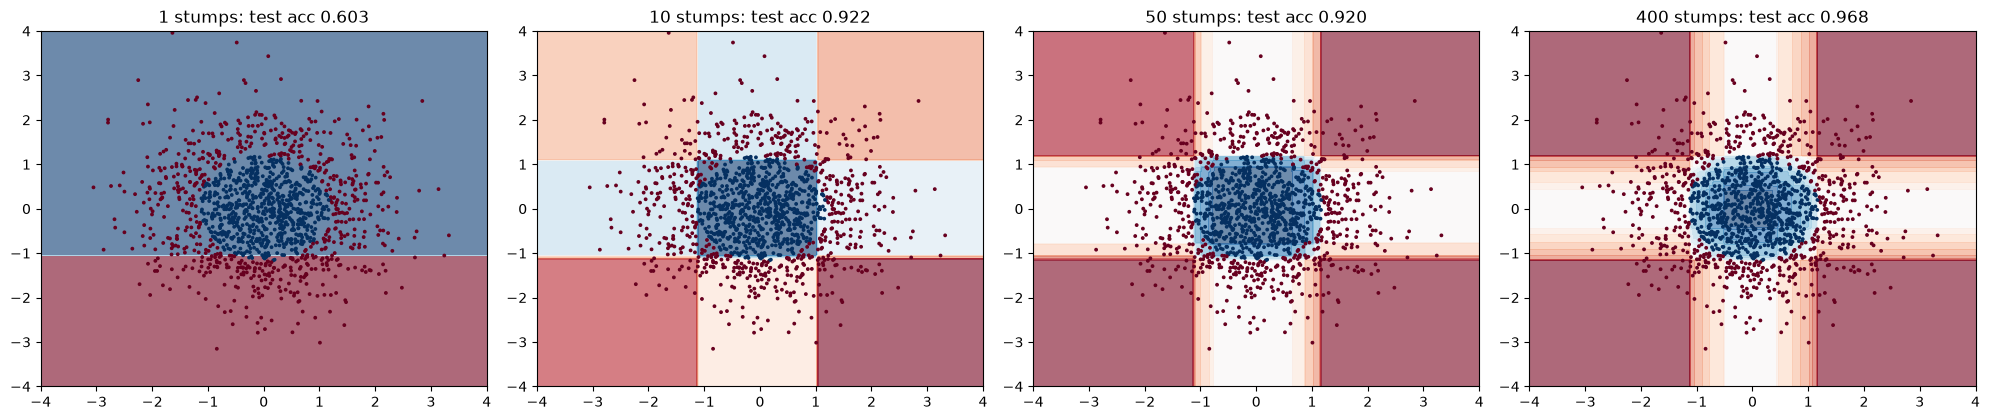

sklearn AdaBoost (400 stumps): 0.968


In [2]:
class AdaBoostScratch:
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators
    def fit(self, X, y):
        y = np.where(y == 1, 1, -1); n = len(y); w = np.full(n, 1 / n)
        self.learners_, self.alphas_ = [], []
        for _ in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1).fit(X, y, sample_weight=w)
            pred = stump.predict(X)
            err = np.clip(np.sum(w * (pred != y)), 1e-10, 1 - 1e-10)
            alpha = 0.5 * np.log((1 - err) / err)
            w = w * np.exp(-alpha * y * pred); w /= w.sum()
            self.learners_.append(stump); self.alphas_.append(alpha)
        return self
    def decision_function(self, X, n=None):
        return sum(a * h.predict(X) for a, h in list(zip(self.alphas_, self.learners_))[:n])
    def predict(self, X, n=None):
        return (self.decision_function(X, n) > 0).astype(int)

from sklearn.datasets import make_gaussian_quantiles
X, y = make_gaussian_quantiles(n_samples=2000, n_features=2, n_classes=2, random_state=1)   # circular boundary: hard for stumps
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
ada = AdaBoostScratch(400).fit(X_tr, y_tr)
xx, yy = np.meshgrid(np.linspace(-4, 4, 250), np.linspace(-4, 4, 250)); grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, m in zip(axes, [1, 10, 50, 400]):
    ax.contourf(xx, yy, ada.decision_function(grid, m).reshape(xx.shape), levels=20, cmap="RdBu_r", alpha=0.6)
    ax.scatter(*X_tr.T, c=y_tr, cmap="RdBu_r", s=3); ax.set_title(f"{m} stumps: test acc {accuracy_score(y_te, ada.predict(X_te, m)):.3f}")
plt.tight_layout(); plt.show()

from sklearn.ensemble import AdaBoostClassifier
print("sklearn AdaBoost (400 stumps):", round(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=400, random_state=0).fit(X_tr, y_tr).score(X_te, y_te), 3))

Each stump alone is a single axis-parallel line (accuracy ~50% here); hundreds of weighted stumps approximate a circle. **Boosting turns weak learners into a strong one.** Its weakness: exponential loss grows very fast for misclassified points, so AdaBoost is sensitive to **label noise and outliers**.

## **2. Gradient Boosting: Gradient Descent in Function Space**
We want $F$ minimising $\sum_i L(y_i, F(x_i))$. Start with a constant $F_0$. At each step compute the **negative gradient** (pseudo-residual) for every sample:
$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$
Fit a small regression tree $h_m$ to the $r_{im}$, then update $F_m = F_{m-1} + \eta\, h_m$ ($\eta$ = learning rate).

For squared loss $L = \frac12(y-F)^2$, the negative gradient is simply the **residual** $y - F$.

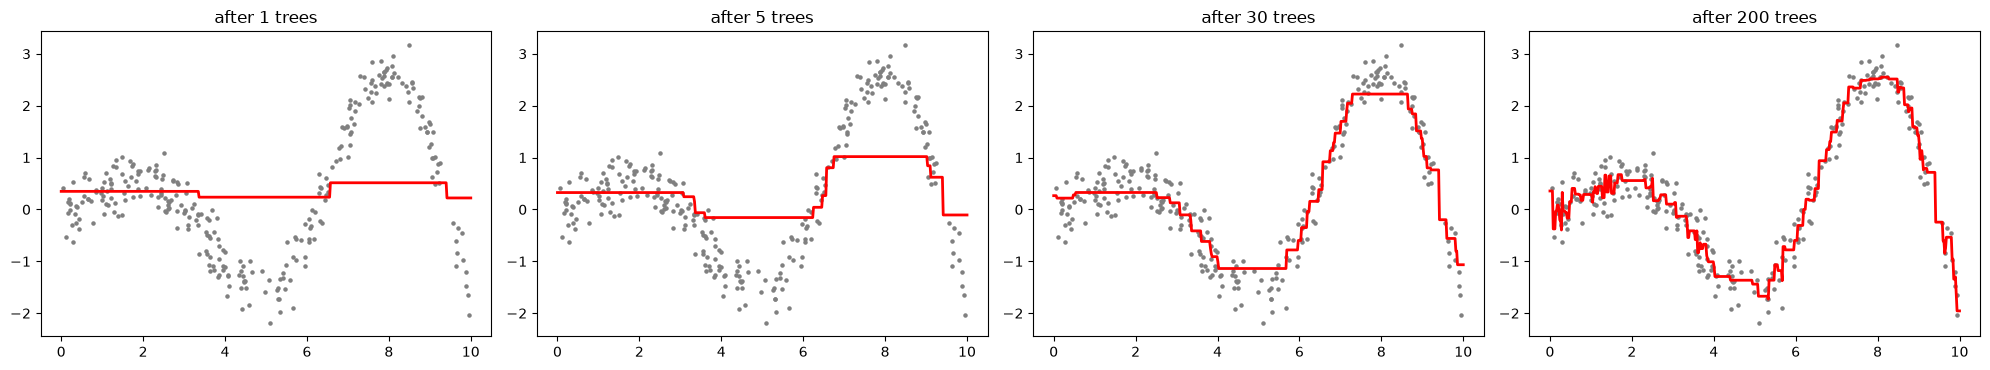

max |scratch - sklearn| prediction difference: 0.0


In [3]:
class GradientBoostingRegressorScratch:
    def __init__(self, n_estimators=200, learning_rate=0.1, max_depth=3, subsample=1.0, seed=0):
        self.n_estimators, self.learning_rate, self.max_depth, self.subsample, self.seed = n_estimators, learning_rate, max_depth, subsample, seed
    def fit(self, X, y):
        r = np.random.default_rng(self.seed)
        self.f0_ = y.mean(); F = np.full(len(y), self.f0_); self.trees_ = []
        for _ in range(self.n_estimators):
            residual = y - F                                              # negative gradient of squared loss
            idx = r.choice(len(y), int(self.subsample * len(y)), replace=False) if self.subsample < 1 else np.arange(len(y))
            tree = DecisionTreeRegressor(max_depth=self.max_depth).fit(X[idx], residual[idx])
            F += self.learning_rate * tree.predict(X); self.trees_.append(tree)
        return self
    def predict(self, X, n=None):
        return self.f0_ + self.learning_rate * sum(t.predict(X) for t in self.trees_[:n])

x = np.sort(rng.uniform(0, 10, 300)); yv = np.sin(x) * x / 3 + rng.normal(0, 0.3, 300)
gb = GradientBoostingRegressorScratch(200, 0.1, max_depth=2).fit(x[:, None], yv)
g = np.linspace(0, 10, 500)[:, None]
fig, axes = plt.subplots(1, 4, figsize=(20, 3.8))
for ax, m in zip(axes, [1, 5, 30, 200]):
    ax.scatter(x, yv, s=5, c="grey"); ax.plot(g, gb.predict(g, m), "r", lw=2); ax.set_title(f"after {m} trees")
plt.tight_layout(); plt.show()

from sklearn.ensemble import GradientBoostingRegressor
sk_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=2, random_state=0).fit(x[:, None], yv)
print("max |scratch - sklearn| prediction difference:", np.abs(gb.predict(g) - sk_gb.predict(g)).max().round(6))

## **3. Hyperparameters and the Learning-Rate / Trees Trade-off**

| Parameter | Role | Typical |
|---|---|---|
| `learning_rate` (shrinkage) | Step size; smaller = better generalisation, needs more trees | 0.01-0.1 |
| `n_estimators` | Number of boosting rounds; **can overfit** (unlike RF) | choose by early stopping |
| `max_depth` / `max_leaf_nodes` | Interaction order of each tree | 3-8 |
| `subsample` | Row sampling per tree (**stochastic** gradient boosting) | 0.5-0.9 |
| `min_samples_leaf` | Smoothness | 5-50 |
| `max_features` | Column sampling | 0.5-1.0 |

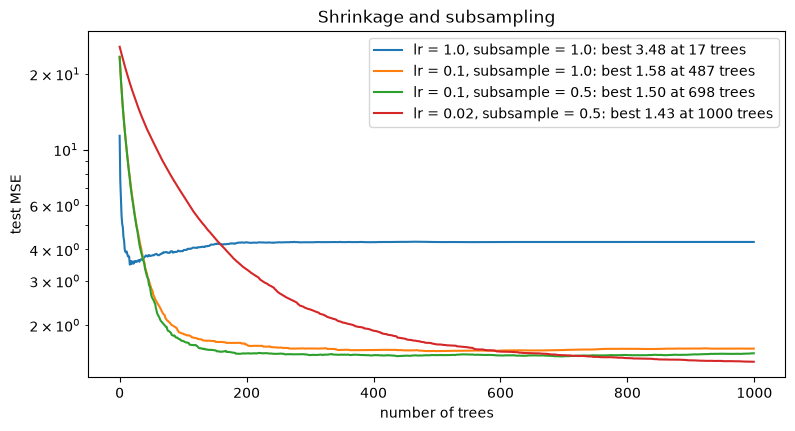

In [4]:
from sklearn.datasets import make_friedman1
Xf, yf = make_friedman1(3000, noise=1.0, random_state=0)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, random_state=0)
plt.figure(figsize=(9, 4.5))
for lr, sub in [(1.0, 1.0), (0.1, 1.0), (0.1, 0.5), (0.02, 0.5)]:
    m = GradientBoostingRegressor(n_estimators=1000, learning_rate=lr, max_depth=3, subsample=sub, random_state=0).fit(Xf_tr, yf_tr)
    test_err = [mean_squared_error(yf_te, p) for p in m.staged_predict(Xf_te)]
    plt.plot(test_err, label=f"lr = {lr}, subsample = {sub}: best {min(test_err):.2f} at {np.argmin(test_err) + 1} trees")
plt.yscale("log"); plt.xlabel("number of trees"); plt.ylabel("test MSE"); plt.legend(); plt.title("Shrinkage and subsampling"); plt.show()

Large learning rates overfit quickly. Small learning rates + subsampling reach a lower error but need more trees.

## **4. Early Stopping**
Hold out a validation fraction; stop when the validation loss has not improved for `n_iter_no_change` rounds.

In [5]:
es = GradientBoostingRegressor(n_estimators=5000, learning_rate=0.05, max_depth=3, subsample=0.8,
                               validation_fraction=0.15, n_iter_no_change=30, random_state=0).fit(Xf_tr, yf_tr)
print(f"early stopping chose {es.n_estimators_} trees | test MSE {mean_squared_error(yf_te, es.predict(Xf_te)):.3f}")

early stopping chose 493 trees | test MSE 1.524


## **5. HistGradientBoosting: Fast and Practical**
Bins each feature into <= 255 histogram buckets (LightGBM-style), so split finding is fast on large data. Supports **missing values** and **categorical features** natively, early stopping by default for n > 10,000, and monotonic constraints.

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
import time
Xbig, ybig = make_friedman1(200_000, noise=1.0, random_state=1)
Xbig[rng.random(Xbig.shape) < 0.05] = np.nan                          # 5% missing values: no imputation needed
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xbig, ybig, test_size=0.2, random_state=0)
t = time.perf_counter()
hgb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.1, early_stopping=True, random_state=0).fit(Xb_tr, yb_tr)
print(f"HistGradientBoosting on 160k rows with NaNs: {time.perf_counter() - t:.1f}s, {hgb.n_iter_} iterations, test R2 {hgb.score(Xb_te, yb_te):.4f}")

HistGradientBoosting on 160k rows with NaNs: 0.7s, 159 iterations, test R2 0.9031


### Monotonic constraints
Domain knowledge such as "landslide susceptibility never decreases with slope" can be enforced: `monotonic_cst=[1, 0, -1, ...]` (+1 increasing, -1 decreasing, 0 free). This improves extrapolation and trust.

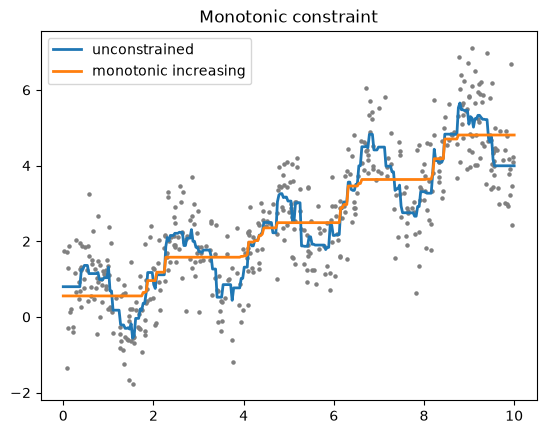

In [7]:
xm = rng.uniform(0, 10, (500, 1)); ym = 0.5 * xm.ravel() + np.sin(3 * xm.ravel()) + rng.normal(0, 0.8, 500)
gm = np.linspace(0, 10, 300)[:, None]
plt.scatter(xm, ym, s=5, c="grey")
for cst, lab in [([0], "unconstrained"), ([1], "monotonic increasing")]:
    plt.plot(gm, HistGradientBoostingRegressor(monotonic_cst=cst, random_state=0).fit(xm, ym).predict(gm), lw=2, label=lab)
plt.legend(); plt.title("Monotonic constraint"); plt.show()

# **Part 2: Going Deeper**

### Gradient boosting for classification (log-loss) from scratch
Model the log-odds $F(x)$; $p = \sigma(F)$. For log-loss, the negative gradient is $y - p$ (Day 8). Each tree fits $y - p$. A Newton step sets each leaf value to $\frac{\sum r_i}{\sum p_i(1-p_i)}$ (gradient / Hessian), which is the core idea of XGBoost (Day 38).

In [8]:
from scipy.special import expit
class GBClassifierScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth
    def fit(self, X, y):
        p0 = y.mean(); self.f0_ = np.log(p0 / (1 - p0)); F = np.full(len(y), self.f0_); self.trees_ = []
        for _ in range(self.n_estimators):
            p = expit(F); grad = y - p; hess = p * (1 - p)
            tree = DecisionTreeRegressor(max_depth=self.max_depth).fit(X, grad)
            leaf = tree.apply(X); values = {}
            for l in np.unique(leaf):                                     # Newton step per leaf
                m = leaf == l; values[l] = grad[m].sum() / (hess[m].sum() + 1e-12)
            F += self.learning_rate * np.vectorize(values.get)(leaf); self.trees_.append((tree, values))
        return self
    def decision_function(self, X):
        F = np.full(len(X), self.f0_)
        for tree, values in self.trees_:
            F += self.learning_rate * np.vectorize(values.get)(tree.apply(X))
        return F
    def predict_proba(self, X):
        p = expit(self.decision_function(X)); return np.c_[1 - p, p]

from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
Xc, yc = make_classification(3000, 20, n_informative=8, random_state=0)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, random_state=0)
mine = GBClassifierScratch(150, 0.1, 3).fit(Xc_tr, yc_tr)
sk = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=0).fit(Xc_tr, yc_tr)
print(f"scratch: acc {accuracy_score(yc_te, mine.predict_proba(Xc_te).argmax(1)):.3f}, log loss {log_loss(yc_te, mine.predict_proba(Xc_te)):.4f}")
print(f"sklearn: acc {sk.score(Xc_te, yc_te):.3f}, log loss {log_loss(yc_te, sk.predict_proba(Xc_te)):.4f}")

scratch: acc 0.945, log loss 0.1439
sklearn: acc 0.944, log loss 0.1441


### AdaBoost vs gradient boosting under label noise

In [9]:
for noise in [0.0, 0.1, 0.2]:
    yn = yc_tr.copy(); flip = rng.random(len(yn)) < noise; yn[flip] = 1 - yn[flip]
    a = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=300, random_state=0).fit(Xc_tr, yn).score(Xc_te, yc_te)
    g_ = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=0).fit(Xc_tr, yn).score(Xc_te, yc_te)
    print(f"label noise {noise:.0%}: AdaBoost {a:.3f} | gradient boosting (log-loss) {g_:.3f}")

label noise 0%: AdaBoost 0.945 | gradient boosting (log-loss) 0.945


label noise 10%: AdaBoost 0.891 | gradient boosting (log-loss) 0.929


label noise 20%: AdaBoost 0.860 | gradient boosting (log-loss) 0.901


## **Practice Problems**
1. Plot the training exponential loss of `AdaBoostScratch` against the number of stumps. Is it monotonic?
2. Implement gradient boosting with the **absolute loss** (negative gradient = sign of the residual). Compare with squared loss on data with outliers.
3. Use `HistGradientBoostingClassifier` with `categorical_features` on a dataset with a 50-level categorical column.
4. *(Advanced)* With one feature, 3 boosted stumps (`learning_rate=1`) and a single depth-2 tree can both represent a step function with at most 4 levels. Compare their training MSE. Why do they differ even though the function classes are the same? (Hint: both are greedy, but along different search paths.)

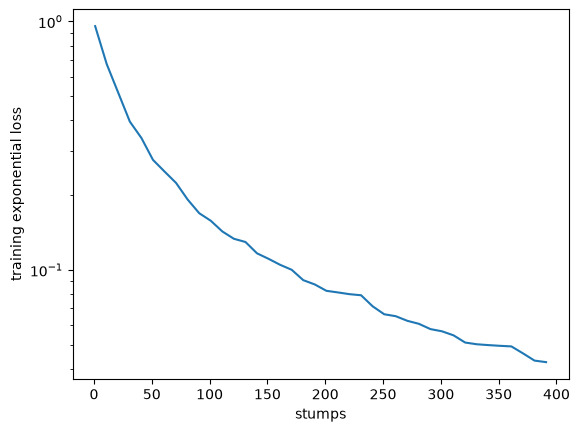

squared loss: MSE against the clean signal = 8.123
absolute loss: MSE against the clean signal = 0.227


categorical_features=None: CV acc 0.820


categorical_features=[0]: CV acc 0.825
1 stump(s), lr=1: train MSE 0.7934
2 stump(s), lr=1: train MSE 0.5385
3 stump(s), lr=1: train MSE 0.4374
one depth-2 tree    : train MSE 0.3042
Stagewise boosting fixes each stump's split before choosing the next; the depth-2 tree chooses its two
child splits conditionally on the root split. Same function class, different greedy paths, different optima.


In [10]:
# Solution 1
ys_pm = np.where(y_tr == 1, 1, -1)
exp_loss = [np.mean(np.exp(-ys_pm * ada.decision_function(X_tr, m))) for m in range(1, 401, 10)]
plt.plot(range(1, 401, 10), exp_loss); plt.yscale("log"); plt.xlabel("stumps"); plt.ylabel("training exponential loss"); plt.show()
# Solution 2
class GBAbs(GradientBoostingRegressorScratch):
    def fit(self, X, y):
        self.f0_ = np.median(y); F = np.full(len(y), self.f0_); self.trees_ = []
        for _ in range(self.n_estimators):
            t = DecisionTreeRegressor(max_depth=self.max_depth).fit(X, np.sign(y - F)); F += self.learning_rate * t.predict(X); self.trees_.append(t)
        return self
y_out = yv.copy(); y_out[rng.choice(300, 15, replace=False)] += 15
for name, m in [("squared", GradientBoostingRegressorScratch(300, 0.1, 2)), ("absolute", GBAbs(300, 0.1, 2))]:
    m.fit(x[:, None], y_out); print(f"{name} loss: MSE against the clean signal = {mean_squared_error(np.sin(x) * x / 3, m.predict(x[:, None])):.3f}")
# Solution 3
from sklearn.ensemble import HistGradientBoostingClassifier
cat = rng.integers(0, 50, 5000); effect = rng.normal(0, 1.5, 50)
Xcat = np.c_[cat, rng.normal(size=(5000, 3))]; ycat = (effect[cat] + Xcat[:, 1] + rng.normal(0, 1, 5000) > 0).astype(int)
for cf in [None, [0]]:
    print(f"categorical_features={cf}: CV acc {cross_val_score(HistGradientBoostingClassifier(categorical_features=cf, random_state=0), Xcat, ycat, cv=5).mean():.3f}")
# Solution 4
for k in [1, 2, 3]:
    m = GradientBoostingRegressorScratch(k, 1.0, 1).fit(x[:, None], yv)
    print(f"{k} stump(s), lr=1: train MSE {mean_squared_error(yv, m.predict(x[:, None])):.4f}")
print(f"one depth-2 tree    : train MSE {mean_squared_error(yv, DecisionTreeRegressor(max_depth=2).fit(x[:, None], yv).predict(x[:, None])):.4f}")
print("Stagewise boosting fixes each stump's split before choosing the next; the depth-2 tree chooses its two")
print("child splits conditionally on the root split. Same function class, different greedy paths, different optima.")

## **Key References**
- Freund, Y., & Schapire, R. E. (1997). A decision-theoretic generalization of on-line learning and an application to boosting. *Journal of Computer and System Sciences*, 55(1), 119-139.
- Friedman, J., Hastie, T., & Tibshirani, R. (2000). Additive logistic regression: A statistical view of boosting. *The Annals of Statistics*, 28(2), 337-407.
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189-1232.
- Friedman, J. H. (2002). Stochastic gradient boosting. *Computational Statistics & Data Analysis*, 38(4), 367-378.
- Natekin, A., & Knoll, A. (2013). Gradient boosting machines, a tutorial. *Frontiers in Neurorobotics*, 7, 21.